<a href="https://colab.research.google.com/github/akhilakorada12/MyCodes/blob/main/DataEngg_ML_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Problem Statement -1

A company wants to predict employee productivity scores to improve workforce planning and training programs. You are hired as a Data Scientist to build a multivariate linear regression model that predicts an employee’s Productivity Score based on multiple work-related factors.

Experience (yrs), Training Hours, Working Hours, Projects, Productivity Score

2,40,38,3,62

5,60,42,6,78

1,20,35,2,55

8,80,45,8,88

4,50,40,5,72

10,90,48,9,92

3,30,37,4,65

6,70,44,7,82

7,75,46,7,85

2,25,36,3,60

Interpretation

Which factor most strongly impacts productivity?

How does training affect productivity?

Should the company increase training hours or working hours?

What happens if Working Hours increase beyond optimal limits?

Can productivity ever decrease with more experience?

How would you detect overfitting in this model?

Suggest one new feature to improve prediction accuracy.



In [ ]:
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
# Creating dataset based on given problem
data = {
    "Experience": [2,5,1,8,4,10,3,6,7,2],
    "Training": [40,60,20,80,50,90,30,70,75,25],
    "WorkingHours": [38,42,35,45,40,48,37,44,46,36],
    "Projects": [3,6,2,8,5,9,4,7,7,3],
    "Productivity": [62,78,55,88,72,92,65,82,85,60]
}
# Convert into DataFrame
df = pd.DataFrame(data)

print("Dataset:\n", df)

Dataset:
    Experience  Training  WorkingHours  Projects  Productivity
0           2        40            38         3            62
1           5        60            42         6            78
2           1        20            35         2            55
3           8        80            45         8            88
4           4        50            40         5            72
5          10        90            48         9            92
6           3        30            37         4            65
7           6        70            44         7            82
8           7        75            46         7            85
9           2        25            36         3            60


In [ ]:

# Independent variables (features)
X = df[['Experience', 'Training', 'WorkingHours', 'Projects']]
# Dependent variable (target)
y = df['Productivity']

#build and training the model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [ ]:
#Model Coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

        Feature  Coefficient
0    Experience    -0.963801
1      Training     0.038009
2  WorkingHours     0.819005
3      Projects     4.701357



R^2 Score: 0.9972374438067544


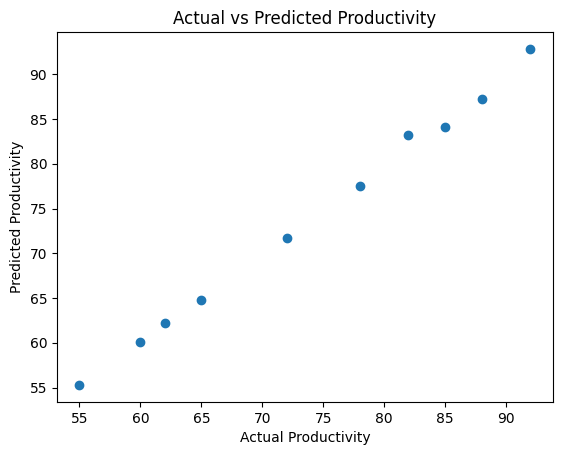

In [ ]:
# Predictions
df["Predicted"] = model.predict(X)

# Model accuracy (R^2 Score)
r2 = model.score(X, y)
print("\nR^2 Score:", r2)

# Visualization (Actual vs Predicted)
plt.scatter(y, df["Predicted"])
plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Actual vs Predicted Productivity")
plt.show()

problem statement -2
Credit Card Fraud Detection

A bank wants to detect fraudulent transactions in real time.
Each transaction must be classified as:

0 → Legitimate  

1 → Fraud
Data Set

TransactionID,Amount,TimeSinceLastTxn,LocationChange,AvgTxnAmount,IsForeignTransaction,IsHighRiskCountry,CardPresent,IsFraud
1,1200,2,1,500,1,1,0,1
2,50,24,0,200,0,0,1,0
3,5000,1,1,450,1,1,0,1
4,200,48,0,300,0,0,1,0
5,1500,3,1,700,1,0,0,1
6,75,72,0,150,0,0,1,0
7,3200,2,1,400,1,1,0,1
8,40,96,0,100,0,0,1,0
9,2100,5,1,600,1,1,0,1
10,60,120,0,120,0,0,1,0

Feature Explanation

Amount → Transaction amount  

TimeSinceLastTxn → Hours since last transaction  

LocationChange → 1 if location differs from previous  

AvgTxnAmount → User’s average spending  

IsForeignTransaction → International transaction  

IsHighRiskCountry → Risky country flag  

CardPresent → Physical card used (0 = online, 1 = swipe)  

IsFraud → Target variable



Interpretation  

Write the logistic regression equation for this dataset.  

How do you interpret model coefficients (e.g., for Amount)?  

What happens if two features are highly correlated?  

Train a logistic regression model on this dataset  

Plot ROC curve  

Tune threshold (not just 0.5)  

Add regularization (L1/L2) and compare results

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

In [ ]:
# dataset
data = {
    "Amount": [1200,50,5000,200,1500,75,3200,40,2100,60],
    "TimeSinceLastTxn": [2,24,1,48,3,72,2,96,5,120],
    "LocationChange": [1,0,1,0,1,0,1,0,1,0],
    "AvgTxnAmount": [500,200,450,300,700,150,400,100,600,120],
    "ForeignTxn": [1,0,1,0,1,0,1,0,1,0],
    "HighRiskCountry": [1,0,1,0,0,0,1,0,1,0],
    "CardPresent": [0,1,0,1,0,1,0,1,0,1],
    "IsFraud": [1,0,1,0,1,0,1,0,1,0]
}
df = pd.DataFrame(data)
print("Dataset:\n", df.head())
# Features and target
X = df.drop("IsFraud", axis=1)
y = df["IsFraud"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Coefficients
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})
print("Model Coefficients:\n")
print(coeff_df)


Dataset:
    Amount  TimeSinceLastTxn  LocationChange  AvgTxnAmount  ForeignTxn  \
0    1200                 2               1           500           1   
1      50                24               0           200           0   
2    5000                 1               1           450           1   
3     200                48               0           300           0   
4    1500                 3               1           700           1   

   HighRiskCountry  CardPresent  IsFraud  
0                1            0        1  
1                0            1        0  
2                1            0        1  
3                0            1        0  
4                0            0        1  
Model Coefficients:

            Feature  Coefficient
0            Amount     0.026585
1  TimeSinceLastTxn    -0.049740
2    LocationChange     0.000050
3      AvgTxnAmount    -0.041688
4        ForeignTxn     0.000050
5   HighRiskCountry     0.000020
6       CardPresent    -0.000538


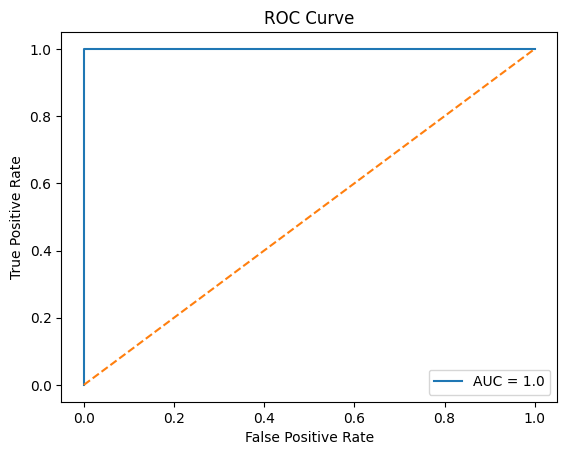

In [ ]:
# Predict probabilities
y_probs = model.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label="AUC = " + str(auc_score))
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [ ]:
# Threshold tuning (example threshold = 0.3)
threshold = 0.3
y_pred_custom = (y_probs >= threshold).astype(int)

print("\nConfusion Matrix (Threshold = 0.3):")
print(confusion_matrix(y_test, y_pred_custom))


Confusion Matrix (Threshold = 0.3):
[[2 0]
 [0 1]]


In [ ]:
#Regularization comparison
# L2
model_l2 = LogisticRegression(penalty='l2', solver='liblinear')
model_l2.fit(X_train, y_train)

# L1
model_l1 = LogisticRegression(penalty='l1', solver='liblinear')
model_l1.fit(X_train, y_train)

print("\nL2 Coefficients:")
print(model_l2.coef_)

print("\nL1 Coefficients:")
print(model_l1.coef_)


L2 Coefficients:
[[ 2.57051811e-02 -4.44782945e-02  4.71858826e-05 -4.17676478e-02
   4.71858826e-05  2.52869441e-05 -4.79428215e-04]]

L1 Coefficients:
[[ 0.01519026 -0.03676511  0.         -0.02235457  0.          0.
   0.        ]]




Problem statement – 3 Customer Segmentation (Retail / E-commerce)

     An e-commerce company wants to segment its customers into groups to:

Personalize marketing campaigns  

Recommend products  

Improve customer retention  

Since there are no labels, we use Clustering (e.g., K-Means).

CustomerID, Age, AnnualIncome, SpendingScore,VisitsPerMonth,AvgOrderValue
1,22,15000,39,4,200
2,25,18000,81,6,500  
3,47,60000,6,2,150

4,52,65000,20,3,200
5,23,20000,77,5,450
6,45,70000,15,2,180
7,33,40000,50,4,300
8,35,42000,55,5,320
9,60,80000,10,1,100
10,28,30000,70,6,400

Feature Explanation

Age → Customer age  

AnnualIncome → Income in ₹  

SpendingScore → Engagement score (1–100)  

VisitsPerMonth → Platform usage frequency  

AvgOrderValue → Average purchase value

Interpretation

Why should you scale features before clustering?  

What happens if features are on different scales?  

Would you include CustomerID in clustering? Why/why not?  

How do you decide the optimal number of clusters (K)?  

Explain Elbow Method and Silhouette Score. Implement the Elbow Method (plot WCSS vs K from 1 to 10). Compute the Silhouette Score for different values of K.  

Load the dataset and perform basic EDA (check nulls, summary stats).  

Normalize/standardize the features using StandardScaler.  

Apply K-Means clustering with k=3.  

Print the cluster labels for each customer.  

Find the centroids of each cluster.

Based on both methods, choose the optimal K.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
# dataset
data = {
    "CustomerID": [1,2,3,4,5,6,7,8,9,10],
    "Age": [22,25,47,52,23,45,33,35,60,28],
    "AnnualIncome": [15000,18000,60000,65000,20000,70000,40000,42000,80000,30000],
    "SpendingScore": [39,81,6,20,77,15,50,55,10,70],
    "VisitsPerMonth": [4,6,2,3,5,2,4,5,1,6],
    "AvgOrderValue": [200,500,150,200,450,180,300,320,100,400]
}

df = pd.DataFrame(data)
print("Dataset:\n", df)

Dataset:
    CustomerID  Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0           1   22         15000             39               4            200
1           2   25         18000             81               6            500
2           3   47         60000              6               2            150
3           4   52         65000             20               3            200
4           5   23         20000             77               5            450
5           6   45         70000             15               2            180
6           7   33         40000             50               4            300
7           8   35         42000             55               5            320
8           9   60         80000             10               1            100
9          10   28         30000             70               6            400


In [ ]:
#EDA
print("\nNull values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())


Null values:
 CustomerID        0
Age               0
AnnualIncome      0
SpendingScore     0
VisitsPerMonth    0
AvgOrderValue     0
dtype: int64

Summary Statistics:
        CustomerID        Age  AnnualIncome  SpendingScore  VisitsPerMonth  \
count    10.00000  10.000000     10.000000      10.000000        10.00000   
mean      5.50000  37.000000  44000.000000      42.300000         3.80000   
std       3.02765  13.266499  23518.314376      28.488009         1.75119   
min       1.00000  22.000000  15000.000000       6.000000         1.00000   
25%       3.25000  25.750000  22500.000000      16.250000         2.25000   
50%       5.50000  34.000000  41000.000000      44.500000         4.00000   
75%       7.75000  46.500000  63750.000000      66.250000         5.00000   
max      10.00000  60.000000  80000.000000      81.000000         6.00000   

       AvgOrderValue  
count      10.000000  
mean      280.000000  
std       135.728487  
min       100.000000  
25%       185.000000 

In [ ]:
#removing customer id as it not represent customer behavior
X = df.drop("CustomerID", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

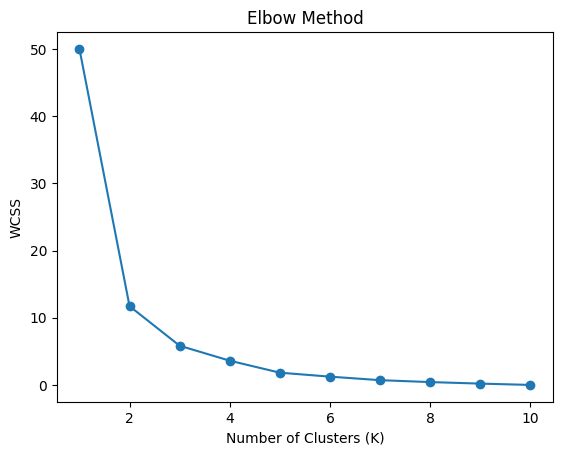

In [ ]:
# Elbow Method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
# Elbow plot
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

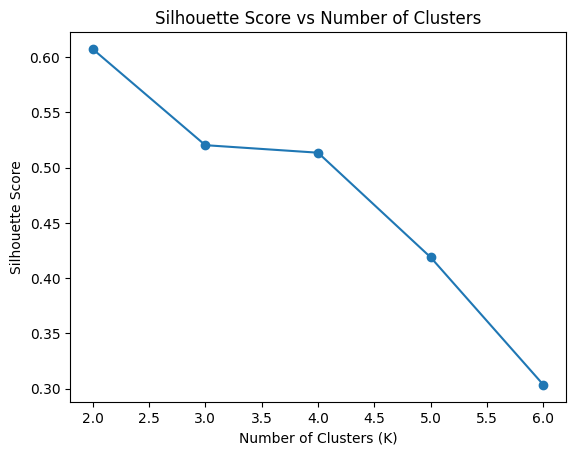

In [ ]:
# Silhouette Score for different K values
silhouette_scores = []
K_values = range(2, 7)   # Silhouette works for K >= 2

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.plot(K_values, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()


In [ ]:
#Applying Final K‑Means
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans_final.fit_predict(X_scaled)
# Print cluster labels
print("\nCustomer Clusters:\n")
print(df[["CustomerID", "Cluster"]])

# Centroids
centroids = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids)

centroid_df = pd.DataFrame(centroids_original, columns=X.columns)
print("\nCluster Centroids:\n")
print(centroid_df)


Customer Clusters:

   CustomerID  Cluster
0           1        2
1           2        1
2           3        0
3           4        0
4           5        1
5           6        0
6           7        2
7           8        2
8           9        0
9          10        1

Cluster Centroids:

         Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0  51.000000  68750.000000          12.75        2.000000     157.500000
1  25.333333  22666.666667          76.00        5.666667     450.000000
2  30.000000  32333.333333          48.00        4.333333     273.333333
